# Cookie Cats A/B Test: Retention vs Monetization

This notebook presents the code written to perform the A/B testing analysis for the cookie cats game dataset, and exposes two different lenses for which to view the outcomes: retention (focus on retention rather than engagement) and monetization (the inverse).
As specified in the dataset information we have, for each user, the group it belongs to (version with gate at level 30 vs level 40), its retention (within the first and the first seven days of playing the game) and the total gamerounds it has initiated.

In [3]:
import numpy as np
import pandas as pd
#Viz
import matplotlib.pyplot as plt
# import seaborn as sns
# Stats
from scipy.stats import chisquare, norm
from statsmodels.stats.proportion import proportions_ztest

In [6]:
# Load the data
data = pd.read_csv('datasets/cookie_cats.csv')

## O. Data Preprocessing
### 0.1 Naming Conventions and Data Types

In [7]:
data.columns = data.columns.str.lower()

for col in ['retention_1', 'retention_7']:
    data[col] = data[col].astype(int)

### 0.2 Removing Outliers

In [ ]:
col = "sum_gamerounds"

log_col = np.log1p(data[col])
q1 = log_col.quantile(0.25)
q3 = log_col.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
mask = (log_col >= lower) & (log_col <= upper)
print(f"Rows before: {data.shape[0]}, after log-IQR filter: {mask.sum()} (removed: {data.shape[0] - mask.sum()})")
data = data[mask].copy()

Rows before: 90189, after log-IQR filter: 90148 (removed: 41)
Rows before: 90189, after removing IQR outliers: 80012, removed: 10177


### 0.3 Quick Checks

In [9]:
null_counts = data.isnull().sum()
print("Any nulls in dataset?:", null_counts.any())

dup_mask = data['userid'].duplicated(keep=False)
dup_any = dup_mask.any()
print(f"\nAny duplicate userids?: {dup_any}")

Any nulls in dataset?: False

Any duplicate userids?: False


## 1. Sample Ratio Mismatch

In [ ]:
prop_b = data["version"].value_counts(normalize=True)
print("\nProportion per version:")
print(prop_b)


Proportion per version (drop_duplicates + value_counts):
version
gate_40    0.504371
gate_30    0.495629
Name: proportion, dtype: float64

Counts of unique users per version:
version
gate_40    45468
gate_30    44680
Name: count, dtype: int64


Percentage of users in each group (percentage) looks almost identical, so it appears to be no hints of wrong sampling procedures during the A/B test.
Still, we'll double-check by running a Chi-Square test on the observed frequencies:

In [14]:
observed = data["version"].value_counts().sort_index()
total = observed.sum()
k = observed.size
print("Observed unique users per version:")
print(observed.to_string())

level = observed.index[0]
count_level = int(observed.iloc[0])
from scipy.stats import binomtest
b = binomtest(count_level, total, p=1/2)
binom_p = b.pvalue
print(f"Binomial test for '{level}' vs 50%: p={binom_p:.4f}")

alpha = 0.001  # or whatever threshold you choose
if binom_p < alpha:
    print(f"\nConclusion (alpha={alpha}): evidence of SRM (p={binom_p:.4f} < {alpha})")
else:
    print(f"\nConclusion (alpha={alpha}): no evidence of SRM (p={binom_p:.4f} >= {alpha})")

Observed unique users per version:
version
gate_30    44680
gate_40    45468
Binomial test for 'gate_30' vs 50%: p=0.0088

Conclusion (alpha=0.001): no evidence of SRM (p=0.0088 >= 0.001)


## Primary Metrics and Guardrails

Depending on the business objective, the metrics can swap roles:

- Retention as Primary Metric and game rounds as Guardrail - If the goal is long-term retention, prioritize for 1-day and 7-day retention and use game rounds to make sure the gate placement does not tank playtime. 
- Game rounds as Primary Metric and retention as Guardrail - If the goal is ad revenue from playtime, prioritize for game rounds and use retention to check that short-term engagement spikes do not cause burnout and churn long-term.

## 2. Analysis
### 2.1 Retention

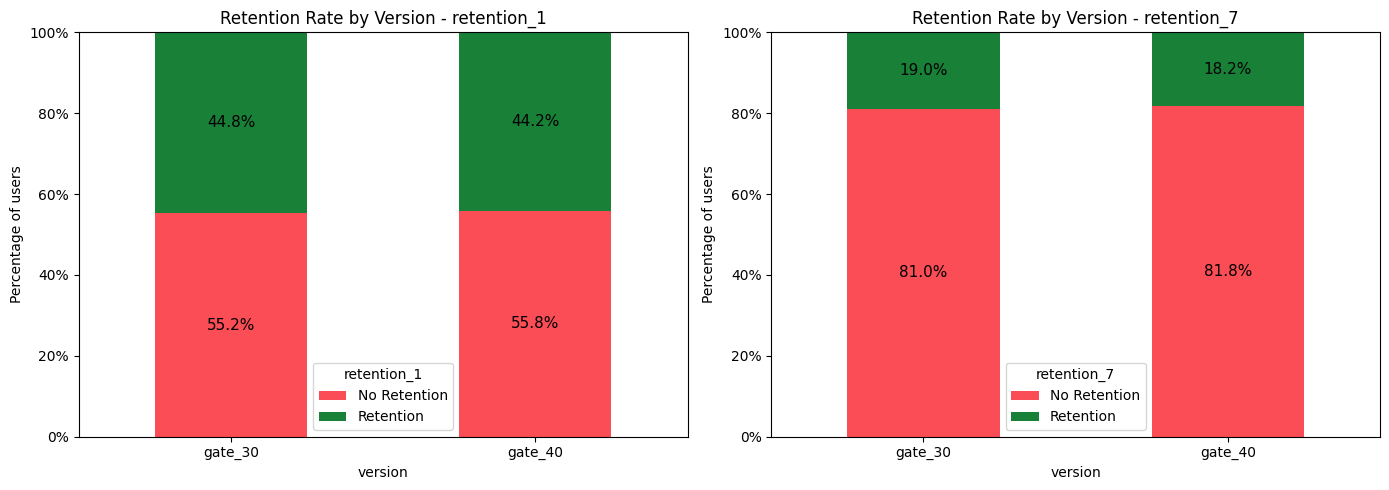

In [25]:
import numpy as np
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_width = 0.5

for i, col in enumerate(["retention_1", "retention_7"]):
    proportions = (
        data.groupby("version")[col]
        .value_counts(normalize = True)
        .unstack()
        .rename(columns={0: "No Retention", 1: "Retention"})
    )
    proportions.plot(kind = "bar", stacked = True, ax = axes[i], color = ["#fa4d56", "#198038"])

    # annotate percentages centered in each segment
    for container in axes[i].containers:
        labels = [f"{v:.1%}" for v in container.datavalues]
        axes[i].bar_label(container, labels = labels, label_type = "center", fontsize = 11)

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(versions, rotation=0)
    axes[i].set_title(f"Retention Rate by Version - {col}")
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].set_ylabel("Percentage of users")
    axes[i].legend(title = col)

plt.tight_layout()
plt.show()